<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/Assumptions_Of_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')

In [4]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [5]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

In [6]:
from sklearn.model_selection import train_test_split
X_train , X_test ,y_train , y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [9]:
y_pred = model.predict(X_test)
residual = y_test - y_pred

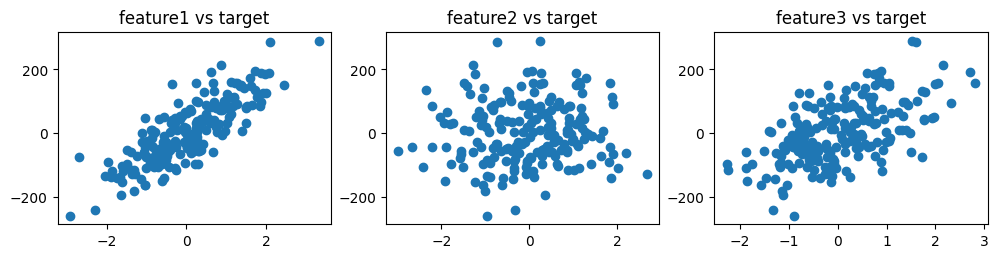

In [10]:
fig,(ax1 ,ax2 , ax3) = plt.subplots(ncols=3 , figsize=(12,2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title('feature1 vs target')

ax2.scatter(df['feature2'], df['target'])
ax2.set_title('feature2 vs target')

ax3.scatter(df['feature3'], df['target'])
ax3.set_title('feature3 vs target')

plt.show()

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
  vif.append(variance_inflation_factor(X_train,i))

In [12]:
pd.DataFrame({'vif' : vif} , index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


<Axes: >

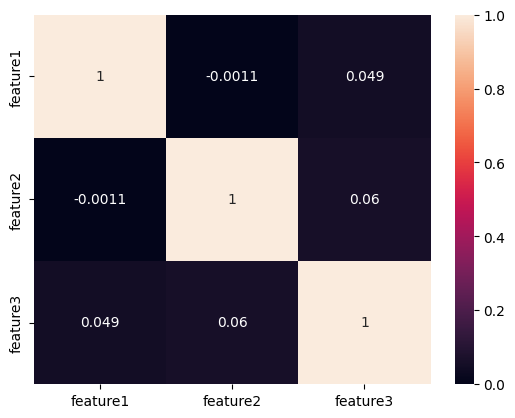

In [13]:
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

<Axes: ylabel='Density'>

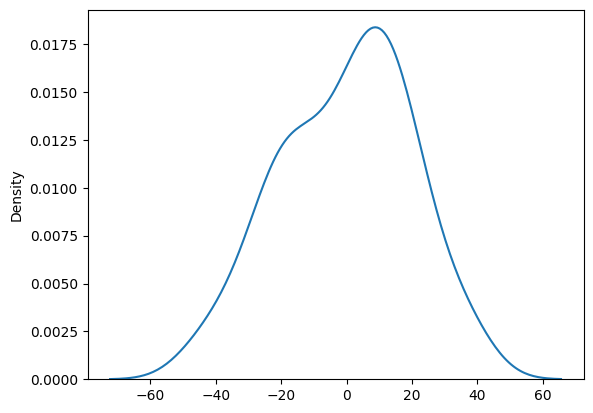

In [16]:
sns.kdeplot(residual)

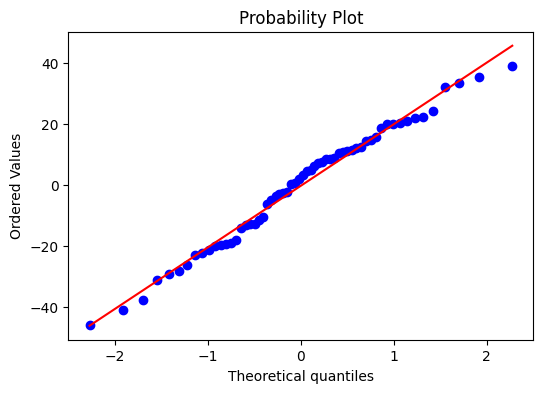

In [18]:
import scipy as sp

fig , ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual,plot=ax,fit=True)
plt.show()

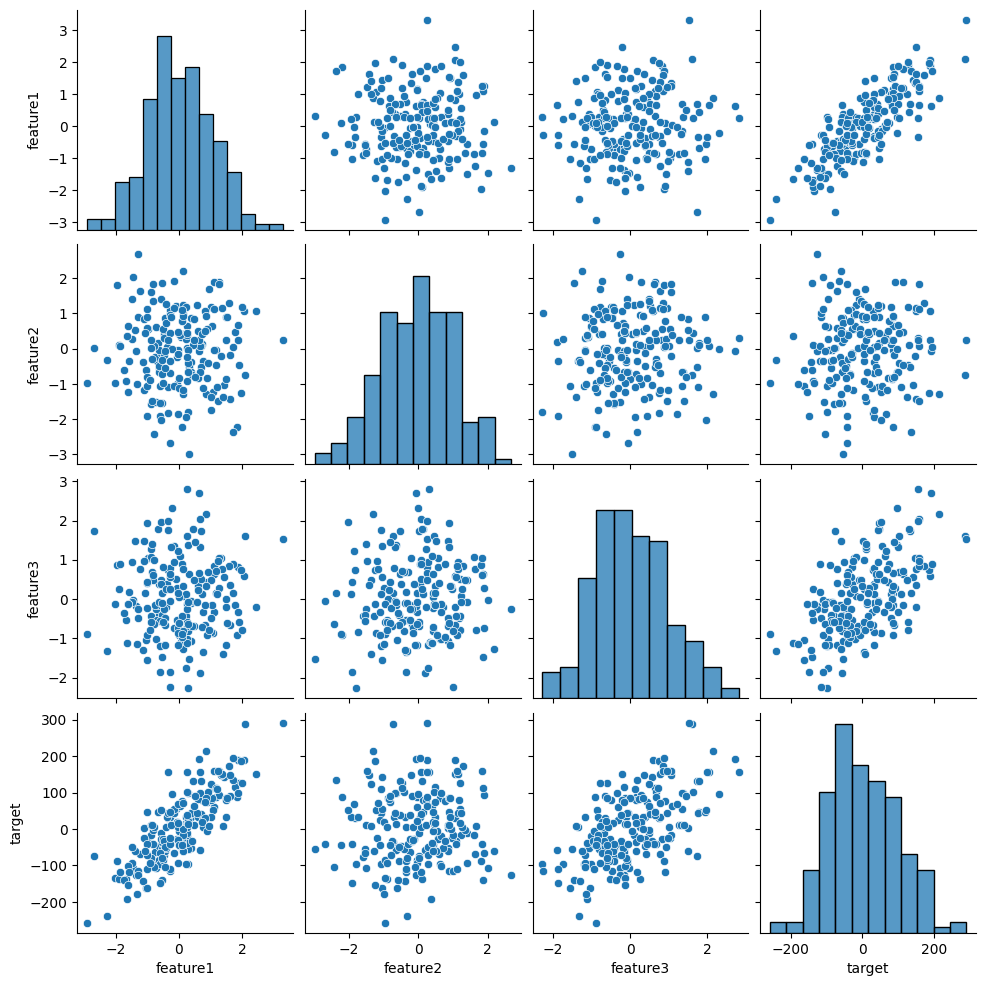

In [20]:
sns.pairplot(df)

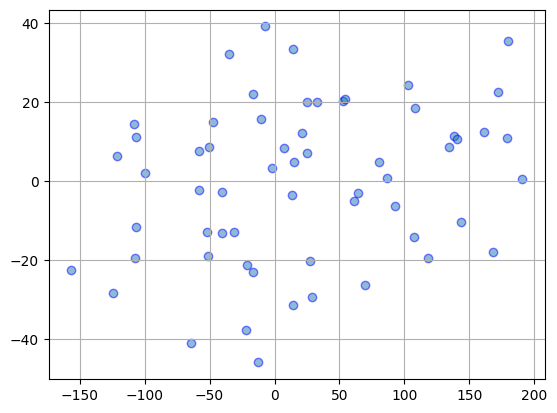

In [23]:
plt.scatter(y_pred, residual , edgecolor='blue' , colorizer='cyan', alpha=0.5)
plt.grid(True)

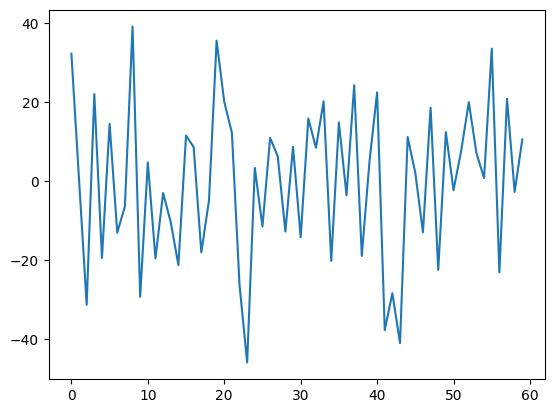

In [24]:
plt.plot(residual)